In [2]:
# Imports
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import mixed_precision
import os
import time
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


2026-03-24 11:57:16.080254: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 11:57:16.106132: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

# Activar Mixed Precision (acelera en GPUs RTX)
mixed_precision.set_global_policy('mixed_float16')

# Variables importantes
ruta_train = "./Training"
ruta_test = "./Testing"
ruta_output = "./Estudios"
#IMG_SIZE = 160
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 12
EPOCHS = 20

GPUs disponibles: []


2026-03-24 11:57:18.754391: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_OPERATING_SYSTEM: OS call failed or operation not supported on this OS


In [4]:
# Normalizamos los datos y generamos los modelos de datos necesarios
"""
Para una red neuronal, el número 255 es "enorme". Esto hace que los gradientes 
(los ajustes que hace la IA para aprender) oscilen demasiado y el entrenamiento 
sea muy lento o incluso no llegue a funcionar.

Al dividir por 255, transformamos ese rango de [0,255] a un rango de [0,1]. Con esto
conseguimos que todos los valores se vuelvan pequeñitos y manejables, y así, la IA 
aprende mucho más rápido y de forma más estable.

"""

tf.config.optimizer.set_jit(True)
# ------------- Train -------------
train_datagen = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    validation_split=0.1,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)


val_datagen = tf.keras.utils.image_dataset_from_directory(
    ruta_train,
    validation_split=0.1,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)


# ------------- Test -------------
test_datagen = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)




# ------------- Normalización -------------
AUTOTUNE = tf.data.AUTOTUNE

train_datagen = (
    train_datagen
    .shuffle(1000)
    .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_datagen = (
    val_datagen
    .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_datagen = (
    test_datagen
    .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("\nDatasets listos 🚀")

Found 1379716 files belonging to 12 classes.
Using 1241745 files for training.
Found 1379716 files belonging to 12 classes.
Using 137971 files for validation.
Found 1088666 files belonging to 12 classes.

Datasets listos 🚀


In [5]:
# Cargar MobileNet preentrenada
MobileNet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

#PARA ENTRENAR SOLO LA PARTE DEL MLP
MobileNet.trainable = False

# Añadir nuestras capas de clasificación
x = MobileNet.output
x = GlobalAveragePooling2D()(x)
#x = Dense(128, activation='relu')(x)
#x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

# Crear el modelo final
model = Model(inputs=MobileNet.input, outputs=predictions)

# Compilar
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n📊 Resumen del modelo:")
model.summary()

# Guardar el modelo
path_modelo = os.path.join(ruta_output, "modelo")
with open(path_modelo, 'w', encoding='utf-8') as f:
    # Pasamos el archivo como parámetro 'print_fn'
    model.summary(print_fn=lambda x: f.write(x + '\n'))

print(f"✅ Summary guardado en: {path_modelo}")



📊 Resumen del modelo:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,273,356 (8.67 MB)

 Trainable params: 15,372 (60.05 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

✅ Summary guardado en: ./Estudios/modelo


In [6]:
# Callbacks para mejorar el entrenamiento
ruta_archivo = os.path.join(ruta_output, "mejor_modelo_mobilenetv2.keras")
callbacks = [
    ModelCheckpoint(
        ruta_archivo,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Callbacks configurados")

✅ Callbacks configurados


In [1]:
print("\n" + "="*60)
print("🎯 COMENZANDO ENTRENAMIENTO")
print("="*60)

start_time = time.time()

history = model.fit(
    train_datagen,
    validation_data=val_datagen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

tiempo_total = time.time() - start_time


# Guardamos los datos en un fichero
ruta_archivo = os.path.join(ruta_output, "MobileNetV2_training.txt")
with open(ruta_archivo, "a", encoding='utf-8') as f:
    f.write(f"Image size = {IMG_SIZE}x{IMG_SIZE}\n")
    f.write(f"Batch size = {BATCH_SIZE}\n")
    f.write(f"Epochs = {EPOCHS}\n")
    f.write(f"Time executing = {tiempo_total}\n")

    # métricas
    f.write(f"Train accuracy: {history.history['accuracy'][-1]:.4f}\n")
    f.write(f"Train loss: {history.history['loss'][-1]:.4f}\n")
    f.write(f"Val accuracy: {history.history['val_accuracy'][-1]:.4f}\n")
    f.write(f"Val loss: {history.history['val_loss'][-1]:.4f}\n\n")
    
    # Mejores métricas
    f.write(f"🏆 MEJORES VALORES:\n")
    best_acc = max(history.history['val_accuracy'])
    best_epoch = history.history['val_accuracy'].index(best_acc) + 1
    f.write(f"Best val accuracy: {best_acc:.4f} (epoch {best_epoch})\n")



print(f"\n✅ ENTRENAMIENTO COMPLETADO en {tiempo_total/60:.2f} minutos")



🎯 COMENZANDO ENTRENAMIENTO


NameError: name 'time' is not defined

📊 RESULTADOS DEL ENTRENAMIENTO
Accuracy final train: 0.9215
Accuracy final val: 0.9479
Mejor val accuracy: 0.9493
17011/17011 ━━━━━━━━━━━━━━━━━━━━ 3739s 220ms/step - accuracy: 0.5890 - loss: 2.5480
Test accuracy: 0.5890357494354248


2026-03-02 04:03:41.169214: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


17011/17011 ━━━━━━━━━━━━━━━━━━━━ 2247s 132ms/step
              precision    recall  f1-score   support

           0       0.01      0.01      0.01     11580
           1       0.03      0.04      0.04     36866
           2       0.04      0.07      0.05     47278
           3       0.14      0.11      0.13    149546
           4       0.12      0.08      0.10    134628
           5       0.03      0.01      0.02     25552
           6       0.01      0.01      0.01     10610
           7       0.12      0.18      0.14    126220
           8       0.38      0.46      0.42    410308
           9       0.02      0.01      0.01     22350
          10       0.05      0.01      0.02     54654
          11       0.05      0.00      0.01     59072

    accuracy                           0.23   1088664
   macro avg       0.08      0.08      0.08   1088664
weighted avg       0.20      0.23      0.21   1088664



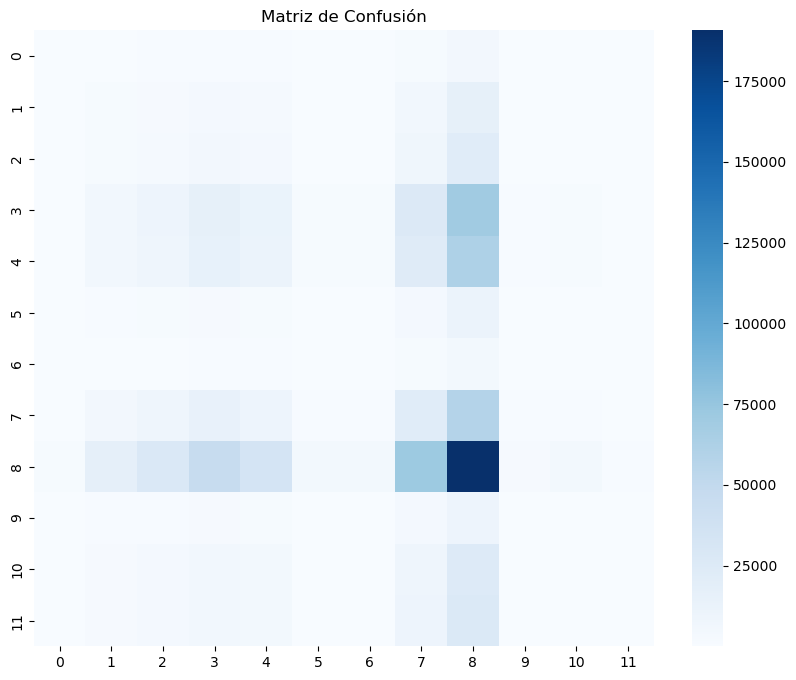

In [7]:
print("📊 RESULTADOS DEL ENTRENAMIENTO")
print("="*50)
print(f"Accuracy final train: {history.history['accuracy'][-1]:.4f}")
print(f"Accuracy final val: {history.history['val_accuracy'][-1]:.4f}")
print(f"Mejor val accuracy: {max(history.history['val_accuracy']):.4f}")

loss, acc = model.evaluate(test_datagen)
print("Test accuracy:", acc)


# repetimos el test generator porque tras su uso se agota
test_datagen = tf.keras.utils.image_dataset_from_directory(
    ruta_test,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_datagen = (
    test_datagen
    .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Matriz de confusión
y_true = np.concatenate([y for x, y in test_datagen], axis=0)
y_pred = model.predict(test_datagen)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()